# CardioIA Fase 4 - Parte 1: Pre-processamento e Organizacao das Imagens

**FIAP | Tecnologo em Inteligencia Artificial | Fase 4 | Capitulo 1 | Grupo 72**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juanvoltolini-rm562890/CardioIA-Fase4-Cap1/blob/main/notebooks/01_preprocessamento.ipynb)

Este notebook implementa a Parte 1 do enunciado:

1. **Download** do dataset publico Chest X-Ray Pneumonia (Kaggle) via `kagglehub`.
2. **Inventario** da divisao original, evidenciando o conjunto de validacao com apenas 16 imagens.
3. **Analise exploratoria**: amostras por classe, dimensoes, formatos e distribuicao de classes/subtipos.
4. **Re-split** 90/10 de treino/validacao (teste original preservado), estratificado por classe e agrupado por paciente, com verificacoes automaticas contra vazamento de dados.
5. **Manifestos** `train.csv`, `val.csv` e `test.csv` para `data/splits/` (consumidos pelos notebooks 02, 03 e 04).
6. **Demonstracao do pipeline**: redimensionamento 224x224, conversao RGB, as duas estrategias de normalizacao e a augmentation do treino.

As justificativas das escolhas estao em `docs/relatorio_parte1_preprocessamento.md`.

## 1. Configuracao do ambiente

Seed fixa para reprodutibilidade. Registramos a versao do TensorFlow porque o `requirements.txt` do prototipo Flask deve pinar a mesma versao.

In [1]:
import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from PIL import Image
from IPython.display import display

SEED = 42
tf.keras.utils.set_random_seed(SEED)

print('TensorFlow:', tf.__version__)
print('GPU disponivel:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU disponivel: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Download do dataset

O `kagglehub` baixa o dataset publico sem credenciais. O zip do Kaggle contem pastas duplicadas (`chest_xray/chest_xray`) e residuos `__MACOSX`, entao localizamos a raiz correta procurando a pasta que contem `train/`, `val/` e `test/`.

In [2]:
import kagglehub

download_root = Path(kagglehub.dataset_download('paultimothymooney/chest-xray-pneumonia'))
print('Dataset baixado em:', download_root)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Dataset baixado em: /kaggle/input/chest-xray-pneumonia


In [3]:
def localizar_raiz_dataset(base: Path) -> Path:
    """Encontra a pasta que contem train/, val/ e test/ (ignora duplicatas e __MACOSX)."""
    candidatos = []
    for dirpath, dirnames, _ in os.walk(base):
        p = Path(dirpath)
        if '__MACOSX' in p.parts:
            continue
        if {'train', 'val', 'test'}.issubset(set(dirnames)):
            candidatos.append(p)
    if not candidatos:
        raise FileNotFoundError(f'Nao encontrei train/val/test abaixo de {base}')
    return sorted(candidatos, key=lambda p: len(p.parts))[0]

DATA_ROOT = localizar_raiz_dataset(download_root)
print('Raiz do dataset:', DATA_ROOT)

Raiz do dataset: /kaggle/input/chest-xray-pneumonia/chest_xray


## 3. Inventario dos splits originais

Para cada imagem registramos o caminho relativo, o split original, a classe, o subtipo de pneumonia (`bacteria`/`virus`, extraido do nome do arquivo) e o identificador do paciente (`personXXXX`, presente apenas nos arquivos de pneumonia).

O ponto critico aparece na tabela: **o conjunto de validacao original tem apenas 16 imagens** (8 por classe), insuficiente para monitorar o treino com EarlyStopping - uma unica imagem desloca a acuracia de validacao em 6,25 pontos percentuais.

In [4]:
EXTENSOES = ('*.jpeg', '*.jpg', '*.png')

def inventariar(root: Path) -> pd.DataFrame:
    registros = []
    for split in ['train', 'val', 'test']:
        for classe in ['NORMAL', 'PNEUMONIA']:
            pasta = root / split / classe
            arquivos = sorted(arq for ext in EXTENSOES for arq in pasta.glob(ext))
            for arq in arquivos:
                m_pessoa = re.search(r'person(\d+)', arq.name)
                m_sub = re.search(r'(bacteria|virus)', arq.name)
                registros.append({
                    'filepath': str(arq.relative_to(root)),
                    'split_original': split,
                    'label': classe,
                    'subtipo': m_sub.group(1) if m_sub else ('normal' if classe == 'NORMAL' else 'desconhecido'),
                    'person_id': m_pessoa.group(1) if m_pessoa else None,
                })
    return pd.DataFrame(registros)

df = inventariar(DATA_ROOT)
print('Total de imagens:', len(df))

tabela_original = df.groupby(['split_original', 'label']).size().unstack(fill_value=0)
tabela_original['total'] = tabela_original.sum(axis=1)
display(tabela_original)

print('\nPacientes distintos com pneumonia:', df[df.label == 'PNEUMONIA'].person_id.nunique())
print('Imagens por subtipo:')
display(df.groupby('subtipo').size())

Total de imagens: 5856


label,NORMAL,PNEUMONIA,total
split_original,,,
test,234,390,624
train,1341,3875,5216
val,8,8,16



Pacientes distintos com pneumonia: 1674
Imagens por subtipo:


,0
subtipo,
bacteria,2780
normal,1583
virus,1493


## 4. Analise exploratoria

### 4.1 Amostras por classe

Radiografias NORMAL apresentam campos pulmonares escuros e bem definidos; nas PNEUMONIA aparecem opacidades (consolidacoes bacterianas mais focais, padroes virais mais difusos).

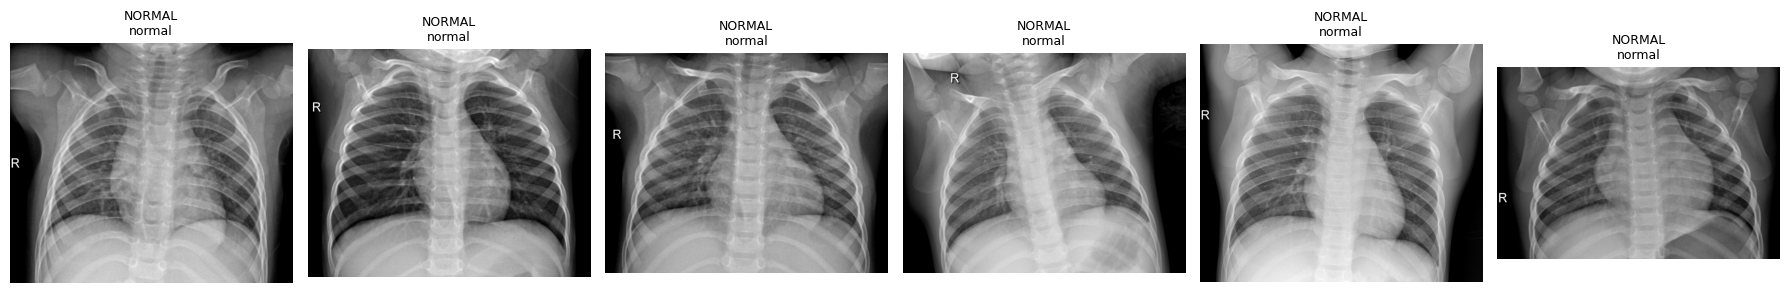

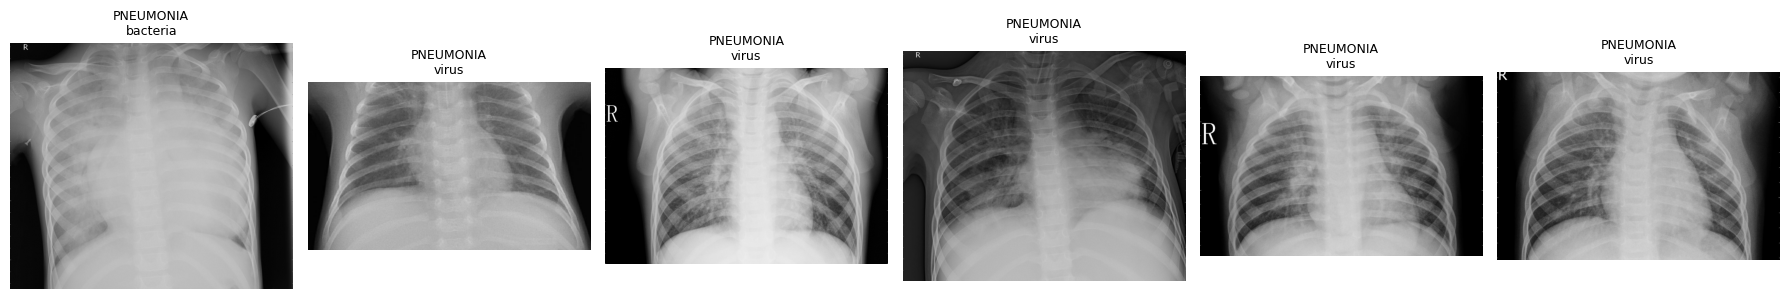

In [5]:
def mostrar_amostras(frame: pd.DataFrame, classe: str, n: int = 6):
    amostras = frame[(frame.label == classe) & (frame.split_original == 'train')].sample(n, random_state=SEED)
    fig, axes = plt.subplots(1, n, figsize=(3 * n, 3.5))
    for ax, (_, linha) in zip(axes, amostras.iterrows()):
        with Image.open(DATA_ROOT / linha.filepath) as img:
            ax.imshow(img, cmap='gray')
        ax.set_title(f'{linha.label}\n{linha.subtipo}', fontsize=9)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

mostrar_amostras(df, 'NORMAL')
mostrar_amostras(df, 'PNEUMONIA')

### 4.2 Dimensoes e formatos originais

As imagens tem tamanhos variados (de ~400 ate ~2900 pixels de largura) e o dataset mistura modos de cor (`L` = grayscale e `RGB`). Isso justifica duas etapas do pipeline: **redimensionamento para um tamanho fixo** e **conversao uniforme para 3 canais**.

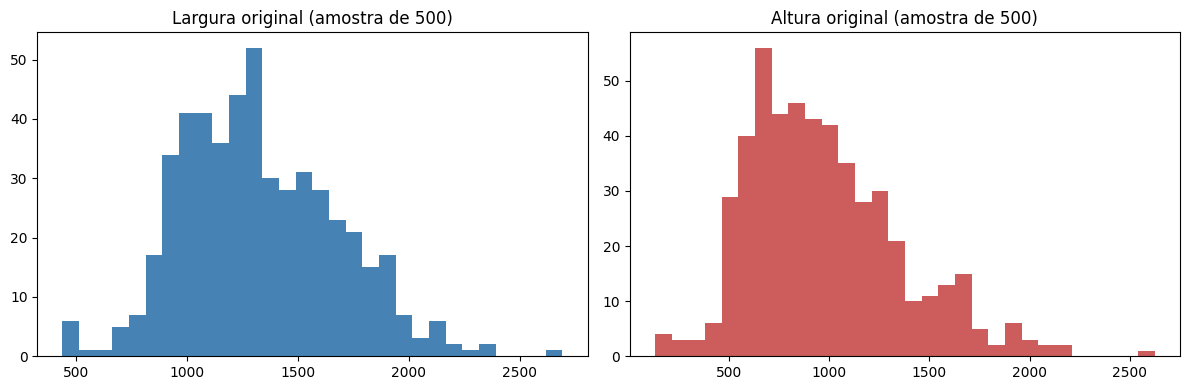

Modos de cor na amostra:


,count
modo,
L,473
RGB,27


In [6]:
amostra_dim = df.sample(500, random_state=SEED).copy()
dims = []
for fp in amostra_dim.filepath:
    with Image.open(DATA_ROOT / fp) as im:
        dims.append((im.size[0], im.size[1], im.mode))
amostra_dim[['largura', 'altura', 'modo']] = pd.DataFrame(dims, index=amostra_dim.index)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(amostra_dim.largura, bins=30, color='steelblue')
axes[0].set_title('Largura original (amostra de 500)')
axes[1].hist(amostra_dim.altura, bins=30, color='indianred')
axes[1].set_title('Altura original (amostra de 500)')
plt.tight_layout()
plt.show()

print('Modos de cor na amostra:')
display(amostra_dim.modo.value_counts())

### 4.3 Distribuicao de classes e subtipos

Cerca de **73% das imagens sao de pneumonia**. Esse desbalanceamento sera tratado no treino com `class_weight`, e a avaliacao reportara sempre metricas por classe (precisao, recall, F1), nunca apenas acuracia.

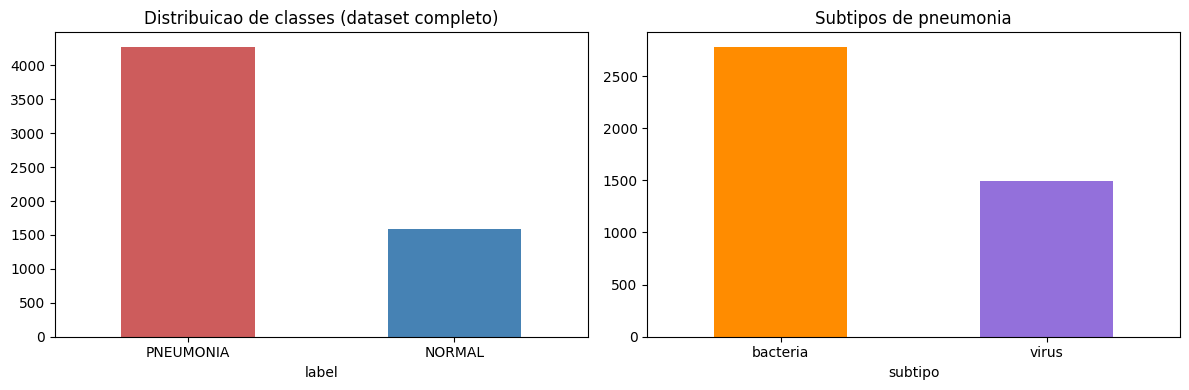

Proporcao PNEUMONIA: 73.0% | NORMAL: 27.0%


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df.label.value_counts().plot.bar(ax=axes[0], color=['indianred', 'steelblue'], rot=0)
axes[0].set_title('Distribuicao de classes (dataset completo)')
df[df.label == 'PNEUMONIA'].subtipo.value_counts().plot.bar(ax=axes[1], color=['darkorange', 'mediumpurple'], rot=0)
axes[1].set_title('Subtipos de pneumonia')
plt.tight_layout()
plt.show()

proporcao = df.label.value_counts(normalize=True)
print(f'Proporcao PNEUMONIA: {proporcao["PNEUMONIA"]:.1%} | NORMAL: {proporcao["NORMAL"]:.1%}')

## 5. Re-split treino / validacao / teste

Estrategia:

- O **teste original (624 imagens) e preservado intacto**, mantendo comparabilidade com a literatura.
- Train + val originais (5.232 imagens) sao fundidos e redivididos em **90% treino / 10% validacao**, por classe.
- Para PNEUMONIA a divisao e **agrupada por paciente** (`GroupShuffleSplit`): ha varias imagens do mesmo paciente e separa-las entre treino e validacao vazaria informacao, inflando as metricas.
- Para NORMAL nao ha identificador de paciente no nome do arquivo (limitacao documentada no relatorio); usamos divisao aleatoria simples com seed fixa.

As verificacoes (`assert`) garantem: nenhuma imagem em mais de um split, nenhum paciente de pneumonia em treino e validacao ao mesmo tempo, e total igual a 5.856.

In [8]:
from sklearn.model_selection import GroupShuffleSplit, train_test_split

df_teste = df[df.split_original == 'test'].copy()
df_treino_val = df[df.split_original != 'test'].copy()

# PNEUMONIA: split agrupado por paciente
pneu = df_treino_val[df_treino_val.label == 'PNEUMONIA'].copy()
pneu['grupo'] = pneu.person_id.fillna(pneu.filepath)  # fallback: arquivo sem person_id vira grupo proprio
gss = GroupShuffleSplit(n_splits=1, test_size=0.10, random_state=SEED)
idx_tr, idx_va = next(gss.split(pneu, groups=pneu.grupo))
pneu_tr, pneu_va = pneu.iloc[idx_tr], pneu.iloc[idx_va]

# NORMAL: sem id de paciente disponivel -> divisao aleatoria simples com seed
norm = df_treino_val[df_treino_val.label == 'NORMAL']
norm_tr, norm_va = train_test_split(norm, test_size=0.10, random_state=SEED)

colunas = ['filepath', 'label', 'subtipo', 'person_id']
df_treino = pd.concat([pneu_tr, norm_tr])[colunas].sample(frac=1, random_state=SEED).reset_index(drop=True)
df_val = pd.concat([pneu_va, norm_va])[colunas].sample(frac=1, random_state=SEED).reset_index(drop=True)
df_teste = df_teste[colunas].reset_index(drop=True)

# Verificacoes contra vazamento
assert set(df_treino.filepath).isdisjoint(df_val.filepath), 'imagem repetida entre treino e validacao'
assert set(df_treino.filepath).isdisjoint(df_teste.filepath), 'imagem repetida entre treino e teste'
assert set(df_val.filepath).isdisjoint(df_teste.filepath), 'imagem repetida entre validacao e teste'
pacientes_tr = set(pneu_tr.grupo)
pacientes_va = set(pneu_va.grupo)
assert pacientes_tr.isdisjoint(pacientes_va), 'vazamento de paciente entre treino e validacao'
total = len(df_treino) + len(df_val) + len(df_teste)
assert total == len(df) == 5856, f'total inesperado: {total}'
print('Verificacoes OK - sem vazamento e total de', total, 'imagens')

resumo = pd.DataFrame({
    'treino': df_treino.label.value_counts(),
    'validacao': df_val.label.value_counts(),
    'teste': df_teste.label.value_counts(),
})
resumo.loc['total'] = resumo.sum()
display(resumo)

# class_weight de referencia para os notebooks de treino (NB02 e NB03)
contagem = df_treino.label.value_counts()
class_weight = {
    0: len(df_treino) / (2 * contagem['NORMAL']),     # 0 = NORMAL
    1: len(df_treino) / (2 * contagem['PNEUMONIA']),  # 1 = PNEUMONIA
}
print('class_weight sugerido para o treino:', {k: round(v, 3) for k, v in class_weight.items()})

Verificacoes OK - sem vazamento e total de 5856 imagens


,treino,validacao,teste
label,,,
PNEUMONIA,3463,420,390
NORMAL,1214,135,234
total,4677,555,624


class_weight sugerido para o treino: {0: np.float64(1.926), 1: np.float64(0.675)}


### 5.1 Gravacao dos manifestos

Os CSVs gerados abaixo devem ser copiados para **`data/splits/`** no repositorio e commitados. Os notebooks 02, 03 e 04 leem esses manifestos em vez de refazer o split, garantindo que todos os integrantes usem exatamente a mesma divisao.

In [9]:
saida = Path('splits_gerados')
saida.mkdir(exist_ok=True)

df_treino.to_csv(saida / 'train.csv', index=False)
df_val.to_csv(saida / 'val.csv', index=False)
df_teste.to_csv(saida / 'test.csv', index=False)
print('Manifestos gravados em', saida.resolve())

try:
    from google.colab import files
    for nome in ['train.csv', 'val.csv', 'test.csv']:
        files.download(str(saida / nome))
except ImportError:
    print('Fora do Colab: copie os CSVs acima para data/splits/ no repositorio.')

Manifestos gravados em /content/splits_gerados


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 6. Pipeline de pre-processamento (demonstracao)

Pipeline `tf.data` usado nos treinos: leitura do JPEG -> decodificacao com **3 canais (conversao RGB)** -> **redimensionamento 224x224** (tamanho nativo do VGG16, padronizado tambem para a CNN do zero).

Sao duas estrategias de **normalizacao**, uma por modelo:

| Modelo | Normalizacao | Onde fica |
|---|---|---|
| CNN do zero | `Rescaling(1/255)` -> pixels em [0, 1] | embutida como primeira camada do modelo |
| VGG16 | `preprocess_input` (BGR + subtracao das medias do ImageNet) | fora do modelo, aplicada no `tf.data` e registrada em `models/model_meta.json` |

Embutir o `Rescaling` no modelo elimina o risco de esquecer a normalizacao na inferencia; o `preprocess_input` fica fora porque envolve uma funcao nao serializavel com seguranca no Keras 3 (`Lambda`).

In [10]:
IMG_SIZE = (224, 224)
BATCH = 32

def carregar_imagem(caminho, label):
    dados = tf.io.read_file(caminho)
    img = tf.io.decode_jpeg(dados, channels=3)        # conversao de formato: sempre 3 canais (RGB)
    img = tf.image.resize(img, IMG_SIZE)              # redimensionamento
    return img, label

def montar_dataset(frame: pd.DataFrame, treino: bool = False) -> tf.data.Dataset:
    caminhos = [str(DATA_ROOT / fp) for fp in frame.filepath]
    labels = (frame.label == 'PNEUMONIA').astype(int).values
    ds = tf.data.Dataset.from_tensor_slices((caminhos, labels))
    ds = ds.map(carregar_imagem, num_parallel_calls=tf.data.AUTOTUNE)
    if treino:
        ds = ds.shuffle(1000, seed=SEED)
    return ds.batch(BATCH).prefetch(tf.data.AUTOTUNE)

ds_demo = montar_dataset(df_val)
lote, lote_labels = next(iter(ds_demo))
print('Lote:', lote.shape, '| intervalo bruto: [', float(tf.reduce_min(lote)), ',', float(tf.reduce_max(lote)), ']')

# Estrategia 1 - CNN do zero: Rescaling(1/255), embutido no modelo
resc = tf.keras.layers.Rescaling(1.0 / 255)(lote)
print('Apos Rescaling(1/255): [', round(float(tf.reduce_min(resc)), 3), ',', round(float(tf.reduce_max(resc)), 3), ']')

# Estrategia 2 - VGG16: preprocess_input, aplicado FORA do modelo
from tensorflow.keras.applications.vgg16 import preprocess_input
vgg = preprocess_input(tf.identity(lote))
medias = [round(float(x), 1) for x in tf.reduce_mean(vgg, axis=[0, 1, 2])]
print('Apos preprocess_input (media por canal, centrada em ~0):', medias)

Lote: (32, 224, 224, 3) | intervalo bruto: [ 0.0 , 255.0 ]
Apos Rescaling(1/255): [ 0.0 , 1.0 ]
Apos preprocess_input (media por canal, centrada em ~0): [16.5, 3.6, -3.3]


### 6.1 Augmentation do treino

Rotacao de +-10 graus, zoom de 10% e translacao de 10% simulam variacoes reais de posicionamento do paciente no exame.

**Sem `RandomFlip("horizontal")`**: espelhar uma radiografia de torax inverte a posicao anatomica do coracao (criaria uma dextrocardia artificial), gerando exemplos clinicamente invalidos. Essa e uma decisao de dominio, nao apenas tecnica.

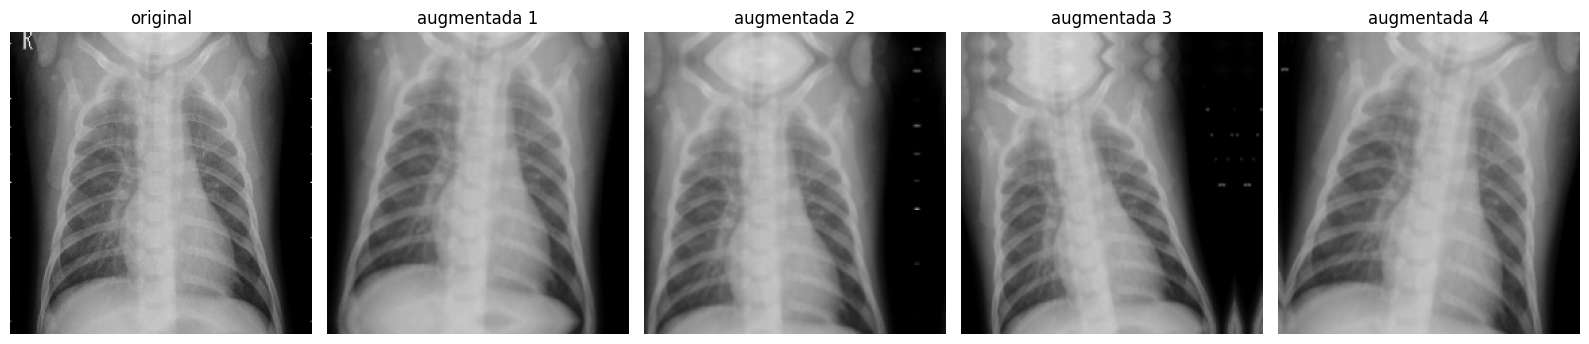

In [11]:
augmentacao = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(10 / 360, seed=SEED),
    tf.keras.layers.RandomZoom(0.1, seed=SEED),
    tf.keras.layers.RandomTranslation(0.1, 0.1, seed=SEED),
], name='augmentation_treino')

img_base = lote[0] / 255.0
fig, axes = plt.subplots(1, 5, figsize=(16, 3.5))
axes[0].imshow(img_base)
axes[0].set_title('original')
axes[0].axis('off')
for i, ax in enumerate(axes[1:], start=1):
    aug = augmentacao(img_base[None, ...], training=True)[0]
    ax.imshow(tf.clip_by_value(aug, 0, 1))
    ax.set_title(f'augmentada {i}')
    ax.axis('off')
plt.tight_layout()
plt.show()

## 7. Resumo das decisoes e proximos passos

| Etapa | Decisao |
|---|---|
| Dataset | Chest X-Ray Pneumonia (Kaggle), 5.856 imagens, NORMAL vs PNEUMONIA |
| Conversao de formato | decodificacao JPEG com 3 canais (RGB uniforme) |
| Redimensionamento | 224x224 (padrao para CNN do zero e VGG16) |
| Normalizacao | `Rescaling(1/255)` embutida (CNN) e `preprocess_input` externa (VGG16) |
| Splits | teste original intacto; treino/validacao 90/10 por classe, agrupado por paciente na pneumonia |
| Desbalanceamento | `class_weight` no treino; metricas por classe na avaliacao |
| Augmentation | rotacao +-10, zoom 0.1, translacao 0.1; sem flip horizontal (anatomia) |

**Proximos passos** (ver `docs/plano_de_trabalho.md`):

1. Copiar `train.csv`, `val.csv` e `test.csv` para `data/splits/` e commitar.
2. `02_cnn_do_zero.ipynb` (Pessoa 2) e `03_transfer_learning.ipynb` (Pessoa 3) consomem os manifestos.
3. O modelo final (`vgg16_finetuned.keras` + `model_meta.json`) alimenta o prototipo Flask e o app mobile.